## 📘 Guia de Uso - Experimentos Automatizados

### 🎯 Objetivo
Este conjunto de células automatiza o teste de **todas as combinações possíveis de features** (de 3 a 6 features por experimento) e salva cada resultado no **MLflow** para análise posterior.

---

### 🛠️ Como Usar

1. **Execute as células** 

2. **Ajuste o número de combinações** (opcional):
   - Por padrão: testa combinações de **3 a 6 features** = **~33.649 experimentos**
   - Para teste rápido: descomente a linha de `random.sample()` na primeira célula para limitar a 100 combinações
   - Para mais features: mude `range(3, 7)` para `range(1, 7)` (vai aumentar MUITO o tempo)

3. **Execute a célula de geração de combinações** (primeira célula criada)

4. **Execute a célula do loop principal** (segunda célula):
   - Vai rodar por **várias horas** dependendo do número de combinações
   - Progress updates a cada 50 experimentos
   - Todos os resultados são salvos no MLflow automaticamente

5. **Execute a célula de análise** para ver:
   - Top 20 melhores combinações
   - Estatísticas por número de features
   - Gráficos comparativos
   - Features mais importantes

6. **(Opcional)** Execute a célula de Random Forest para testar RF na melhor combinação encontrada

---

### 📊 O Que é Salvo no MLflow

Para **cada experimento**:
- **Parâmetros**: features usadas, número de features, tipo de modelo
- **Métricas**: Recall, Precision, F1-Score, **F2-Score**, AUC
- **Modelo**: Pipeline completo (preprocessor + classifier) salvo para deploy

---

### ⏱️ Tempo Estimado

| Combinações | Tempo Aproximado |
|---|---|
| 100 | ~5-10 minutos |
| 1.000 | ~1 hora |
| 10.000 | ~10 horas |
| 33.649 (completo) | ~30-35 horas |

⚠️ **Dica**: Comece com 100 combinações para testar, depois rode o conjunto completo overnight.

---

### 🔍 Como Acessar os Resultados no MLflow

1. Clique em **"Experiments"** no menu lateral esquerdo do Databricks
2. Procure por **`feature_combinations_experiment`**
3. Você pode:
   - Ordenar por qualquer métrica (F2-Score, AUC, Recall...)
   - Comparar múltiplos experimentos lado a lado
   - Fazer download dos modelos salvos
   - Criar gráficos personalizados

---

### 💡 Dicas de Otimização

**Para acelerar os experimentos:**
- Reduza o range de combinações para 4-6 features: `range(4, 7)`
- Use amostragem aleatória: `random.sample(all_combinations, 1000)`
- Teste primeiro só Logistic Regression (mais rápido que Random Forest)

**Para melhorar a qualidade:**
- Adicione mais modelos no loop (XGBoost, LightGBM...)
- Teste diferentes hiperparâmetros para cada combinação
- Use o conjunto de **validação** (`df_val`, `y_val`) para early stopping

---

### ✅ Próximos Passos

Após encontrar a melhor combinação:
1. Teste com **Random Forest** (célula opcional)
2. Faça **Grid Search** detalhado só nas top 10 combinações
3. Use a melhor combinação para **deploy em produção**
4. Salve o modelo final como **Registered Model** no MLflow
5. Testar um ensaio combinado

# Train Test Split


In [0]:
from sklearn.model_selection import train_test_split

# Load Spark DataFrame and convert to pandas for scikit-learn
df_spark = spark.table('adult_income.adult_income_gold.ad_inc_gold')
df_frame = df_spark.toPandas()

# Realizar split estratificado 60/20/20
y = df_frame['class'].apply(lambda x: 1 if x == '>50K' else 0)

# Primeiro split: 60% treino, 40% restante
df_train, df_temp, y_train_temp, y_temp = train_test_split(
    df_frame, y, test_size=0.4, random_state=42, stratify=y
)

# Segundo split: dividir os 40% em 20% validação e 20% teste
df_val, df_test, y_val_temp, y_test_temp = train_test_split(
    df_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Separar features (X) e target (y) para os conjuntos de treino e teste
X_train = df_train.drop(columns=['class'])
y_train = df_train['class'].apply(lambda x: 1 if x == '>50K' else 0)

X_val = df_val.drop(columns=['class'])
y_val = df_val['class'].apply(lambda x: 1 if x == '>50K' else 0)

X_test = df_test.drop(columns=['class'])
y_test = df_test['class'].apply(lambda x: 1 if x == '>50K' else 0)

print("✅ Conjuntos preparados:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape} | Classe positiva (>50K): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape} | Classe positiva (>50K): {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape} | Classe positiva (>50K): {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✅ Conjuntos preparados:
  X_train: (29305, 32)
  y_train: (29305,) | Classe positiva (>50K): 7012 (23.9%)
  X_val: (9768, 32)
  y_val: (9768,) | Classe positiva (>50K): 2337 (23.9%)
  X_test: (9769, 32)
  y_test: (9769,) | Classe positiva (>50K): 2338 (23.9%)


In [0]:
# ✅ VERIFICAÇÃO: Confirmar que os experimentos usam o split correto

print("="*80)
print("📊 VERIFICAÇÃO DO DATA SPLIT")
print("="*80)

print("\n🔢 Tamanhos dos conjuntos:")
print(f"  df_train (Treino):    {df_train.shape[0]:,} registros ({df_train.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  df_val (Validação):   {df_val.shape[0]:,} registros ({df_val.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  df_test (Teste):      {df_test.shape[0]:,} registros ({df_test.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  Total:                {len(df_frame):,} registros")

print("\n✅ CONFIRMAÇÃO:")
print("  - Os experimentos automatizados (Cell 20) TREINAM com 'df_train' (60%)")
print("  - Os experimentos automatizados (Cell 20) AVALIAM com 'df_test' (20%)")
print("  - O conjunto 'df_val' (20%) está disponível para tuning futuro")

print("\n" + "="*80)
print("📝 Código relevante na Cell 20:")
print("="*80)
print("""\n  # Treinar
  X_train_combo = df_train[selected_features]  ← 60% do dataset
  pipeline.fit(X_train_combo, y_train)

  # Prever no conjunto de teste
  X_test_combo = df_test[selected_features]    ← 20% do dataset
  y_pred = pipeline.predict(X_test_combo)
""")

print("="*80)

📊 VERIFICAÇÃO DO DATA SPLIT

🔢 Tamanhos dos conjuntos:
  df_train (Treino):    29,305 registros (60.0%)
  df_val (Validação):   9,768 registros (20.0%)
  df_test (Teste):      9,769 registros (20.0%)
  Total:                48,842 registros

✅ CONFIRMAÇÃO:
  - Os experimentos automatizados (Cell 20) TREINAM com 'df_train' (60%)
  - Os experimentos automatizados (Cell 20) AVALIAM com 'df_test' (20%)
  - O conjunto 'df_val' (20%) está disponível para tuning futuro

📝 Código relevante na Cell 20:

  # Treinar
  X_train_combo = df_train[selected_features]  ← 60% do dataset
  pipeline.fit(X_train_combo, y_train)

  # Prever no conjunto de teste
  X_test_combo = df_test[selected_features]    ← 20% do dataset
  y_pred = pipeline.predict(X_test_combo)



# Pipeline

In [0]:
%pip install xgboost

# vamos importar os transformers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# vamos definir as colunas
selected_columns = [
    'age',
    'capital-loss',
    'class',
    'edu_x_hours',
    'hours-per-week',
    'is_capital_gain',
    'is_capital_loss',
    'is_from_United-States',
    'is_husb_and_not_in_fam',
    'is_husband',
    'is_male',
    'is_married',
    'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private',
    'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
    'is_wife',
    'marital-status',
    'native-country',
    'occupation',
    'race',
    'relationship',
    'sex_ord',
    'workclass',
    'fnlwgt',
]

# variáveis numéricas contínuas -> imputação + scaling
numeric_features = [
    'age',
    'capital-loss',
    'edu_x_hours',
    'education-num',
    'fnlwgt',
    'hours-per-week',
    'sex_ord',
]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# variáveis categóricas nominais -> OneHotEncoder (sem ordem falsa)
categorical_features = [
    'marital-status',
    'native-country',
    'occupation',
    'race',
    'relationship',
    'workclass',
]
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# variáveis binárias (já 0/1) -> só imputação de segurança
binary_features = [
    'is_capital_gain',
    'is_capital_loss',
    'is_from_United-States',
    'is_husb_and_not_in_fam',
    'is_husband',
    'is_male',
    'is_married',
    'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private',
    'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
    'is_wife',
]
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# vamos combinar os processos
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', binary_transformer, binary_features)
])

# --- Pipeline 1: Regressão Logística (usa o preprocessor com scaling) ---
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(max_iter=250))
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 191.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### Aplicar o pipeline

---

# 🧪 Experimentos Automatizados - Combinações de Features

## Objetivo
Testar **automaticamente todas as combinações possíveis de features** (3-6 features por experimento) e salvar todos os resultados no **MLflow** para identificar a melhor combinação que maximiza o **F2-Score** (equilibrando Recall e Precision, com foco em Recall).

## O Que Será Feito
1. ✅ Gerar todas as combinações de 3-6 features
2. ✅ Para cada combinação: treinar Logistic Regression
3. ✅ Avaliar no conjunto de **teste** (df_test)
4. ✅ Salvar métricas e modelo no MLflow
5. ✅ Analisar resultados e identificar as melhores combinações
6. ✅ (Opcional) Testar Random Forest na melhor combinação

---

In [0]:
import itertools
import mlflow
import mlflow.sklearn
from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score, roc_auc_score
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Definir TODAS as features disponíveis (excluindo 'class')
all_numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-loss',
    'hours-per-week',
    'sex_ord',
    'edu_x_hours'
]

all_categorical_features = [
    'marital-status',
    'native-country',
    'occupation',
    'race',
    'relationship',
    'workclass',
]

all_binary_features = [
    'is_capital_gain',
    'is_capital_loss',
    'is_from_United-States', 
    'is_husb_and_not_in_fam',
    'is_husband', 'is_male',
    'is_married', 'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private', 'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
     'is_wife'
]

all_features = all_numeric_features + all_categorical_features + all_binary_features

print(f"Total de features disponíveis: {len(all_features)}")
print(f"Numéricas: {len(all_numeric_features)}")
print(f"Categóricas: {len(all_categorical_features)}")
print(f"Binárias: {len(all_binary_features)}")

# 2. Gerar todas as combinações (de 3 a 6 features para otimizar tempo)
all_combinations = []
for size in range(3, 7):  # 3 a 6 features
    all_combinations.extend(itertools.combinations(all_features, size))

print(f"\nTotal de combinações a testar: {len(all_combinations):,}")
print("Distribuição por tamanho:")
for size in range(3, 7):
    count = len(list(itertools.combinations(all_features, size)))
    print(f"  {size} features: {count:,} combinações")

print(f"\n⚠️ Nota: {len(all_combinations):,} experimentos serão executados. Isso pode levar várias horas.")
print("Para testar rápido, descomente a linha de amostragem aleatória acima.")

Total de features disponíveis: 29
Numéricas: 7
Categóricas: 6
Binárias: 16

Total de combinações a testar: 621,180
Distribuição por tamanho:
  3 features: 3,654 combinações
  4 features: 23,751 combinações
  5 features: 118,755 combinações
  6 features: 475,020 combinações

⚠️ Nota: 621,180 experimentos serão executados. Isso pode levar várias horas.
Para testar rápido, descomente a linha de amostragem aleatória acima.


In [0]:
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score
import random
import pandas as pd


core_features = ['age', 'education-num', 'hours-per-week']  # ajusta às tuas features fixas
candidate_features = [f for f in all_features if f not in core_features]

# versão 6 - calcular scale_pos_weight uma única vez
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {scale_pos_weight:.4f}")

random.seed(42)  # reprodutibilidade caso haja sampling em outras partes do notebook

# separar numéricas, categóricas e binárias dentro de candidate_features
numeric_in_cand = [f for f in candidate_features if f in all_numeric_features]
categorical_in_cand = [f for f in candidate_features if f in all_categorical_features]
binary_in_cand = [f for f in candidate_features if f in all_binary_features]

transformers = []
if numeric_in_cand:
    transformers.append(('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_in_cand))
if categorical_in_cand:
    transformers.append(('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_in_cand))
if binary_in_cand:
    transformers.append(('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ]), binary_in_cand))

preprocessor_quick = ColumnTransformer(transformers=transformers)

# fit no treino, transform treino e validação
preprocessor_quick.fit(df_train[candidate_features])
X_train_transformed = preprocessor_quick.transform(df_train[candidate_features])
X_val_transformed = preprocessor_quick.transform(df_val[candidate_features])

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'n_estimators': [300, 500, 800]
}

f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_transformed, y_train)

print(f"Melhor F2 (CV): {search.best_score_:.4f}")
print(f"Melhores parâmetros: {search.best_params_}")

best_xgb_params = search.best_params_.copy()
best_xgb_params['scale_pos_weight'] = scale_pos_weight
print(best_xgb_params)

# ====== Refit final com early stopping usando os melhores parâmetros ======
xgb_quick = XGBClassifier(
    **search.best_params_,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30
)

xgb_quick.fit(
    X_train_transformed, y_train,
    eval_set=[(X_val_transformed, y_val)],
    verbose=False
)

print(f"Melhor iteração (early stopping): {xgb_quick.best_iteration}")

# feature_importances_ agora referencia as colunas transformadas pelo ColumnTransformer
# (OHE expande cada categórica em N colunas dummy) — usar get_feature_names_out()
# em vez de concatenar listas manualmente
feature_names_transformed = preprocessor_quick.get_feature_names_out()
importances = pd.Series(xgb_quick.feature_importances_, index=feature_names_transformed).sort_values(ascending=False)
display(importances.head(20))

# Agregar importâncias de volta ao nome de feature original
# (soma das dummies do OHE por coluna categórica original)
def original_feature_name(transformed_name):
    name = transformed_name.split('__', 1)[-1]
    for col in categorical_in_cand:
        if name.startswith(col + '_'):
            return col
    return name

importances_by_original = importances.groupby(original_feature_name).sum().sort_values(ascending=False)
display(importances_by_original.head(20))

N_CANDIDATES = 18
optional_features = importances_by_original.head(N_CANDIDATES).index.tolist()
print(f"Features candidatas reduzidas: {optional_features}")

scale_pos_weight calculado: 3.1793
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhor F2 (CV): 0.7733
Melhores parâmetros: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9, 'scale_pos_weight': np.float64(3.1792641186537365)}
Melhor iteração (early stopping): 499


cat__marital-status_Married-civ-spouse    0.303021
bin__is_married                           0.275971
num__edu_x_hours                          0.034812
cat__relationship_Husband                 0.026845
cat__occupation_Exec-managerial           0.024993
bin__is_capital_gain                      0.023133
cat__occupation_Other-service             0.019543
cat__occupation_Prof-specialty            0.018202
num__capital-loss                         0.015387
cat__relationship_Own-child               0.015326
cat__occupation_Farming-fishing           0.015280
cat__marital-status_Never-married         0.014753
cat__occupation_Tech-support              0.014265
cat__occupation_Handlers-cleaners         0.012948
cat__occupation_Transport-moving          0.011985
cat__workclass_Federal-gov                0.011095
cat__native-country_Mexico                0.010814
cat__occupation_Sales                     0.010793
cat__relationship_Wife                    0.009904
cat__occupation_Machine-op-insp

marital-status                    0.324253
is_married                        0.275971
occupation                        0.149625
relationship                      0.068034
edu_x_hours                       0.034812
workclass                         0.031085
is_capital_gain                   0.023133
native-country                    0.020400
capital-loss                      0.015387
is_married_and_not                0.008413
is_capital_loss                   0.007199
is_wife                           0.006847
is_male                           0.006762
race                              0.005781
sex_ord                           0.005010
is_husb_and_not_in_fam            0.003372
is_native-country_missing         0.002839
is_married_notmarried_divorced    0.002290
is_not_private                    0.002032
is_not_white                      0.002013
dtype: float32

Features candidatas reduzidas: ['marital-status', 'is_married', 'occupation', 'relationship', 'edu_x_hours', 'workclass', 'is_capital_gain', 'native-country', 'capital-loss', 'is_married_and_not', 'is_capital_loss', 'is_wife', 'is_male', 'race', 'sex_ord', 'is_husb_and_not_in_fam', 'is_native-country_missing', 'is_married_notmarried_divorced']


In [0]:
import itertools
import random
import time
from datetime import datetime
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

mlflow.set_experiment("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Gerar combinações SÓ sobre as 18 candidatas (não as 38 originais)
all_combos = []
for size in range(3, 9):
    all_combos.extend(itertools.combinations(optional_features, size))


print(f"Espaço total (sobre {len(optional_features)} candidatas): {len(all_combos):,}")
random.seed(42)  # garante que a amostra de combinações é sempre a mesma
sampled_combinations = random.sample(all_combos, min(1500, len(all_combos)))
print(f"Combinações a testar: {len(sampled_combinations)}")

results = []
start_time = time.time()

print(f"Início dos experimentos: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total de experimentos: {len(sampled_combinations):,}\n")

for i, feature_combo in enumerate(sampled_combinations):
    combo_start = time.time()
    selected_features = core_features + list(feature_combo)

    with mlflow.start_run(run_name=f"combo_{i+1}_{len(selected_features)}_features"):
        try:
            numeric_in_combo = [f for f in selected_features if f in all_numeric_features]
            categorical_in_combo = [f for f in selected_features if f in all_categorical_features]
            binary_in_combo = [f for f in selected_features if f in all_binary_features]

            transformers = []
            if numeric_in_combo:
                transformers.append(('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), numeric_in_combo))
            if categorical_in_combo:
                transformers.append(('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]), categorical_in_combo))
            if binary_in_combo:
                transformers.append(('bin', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent'))
                ]), binary_in_combo))

            preprocessor_combo = ColumnTransformer(transformers=transformers)
            pipeline = Pipeline([
                ('preprocessor', preprocessor_combo),
                ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
            ])

            X_train_combo = df_train[selected_features]

            cv_scores_f2 = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
            cv_scores_recall = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring='recall', n_jobs=-1)
            cv_scores_precision = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring='precision', n_jobs=-1)

            f2_mean, f2_std = cv_scores_f2.mean(), cv_scores_f2.std()
            recall_mean = cv_scores_recall.mean()
            precision_mean = cv_scores_precision.mean()

            pipeline.fit(X_train_combo, y_train)

            mlflow.log_param("num_features", len(selected_features))
            mlflow.log_param("features", ", ".join(selected_features))
            mlflow.log_param("num_numeric_features", len(numeric_in_combo))
            mlflow.log_param("num_categorical_features", len(categorical_in_combo))
            mlflow.log_param("num_binary_features", len(binary_in_combo))
            mlflow.log_param("model_type", "XGBClassifier")
            mlflow.log_param("cv_folds", cv.get_n_splits())

            mlflow.log_metric("f2_cv_mean", f2_mean)
            mlflow.log_metric("f2_cv_std", f2_std)
            mlflow.log_metric("recall_cv_mean", recall_mean)
            mlflow.log_metric("precision_cv_mean", precision_mean)

            mlflow.sklearn.log_model(pipeline, "model")

            results.append({
                'experiment_id': i + 1,
                'num_features': len(selected_features),
                'features': ", ".join(selected_features),
                'recall_cv_mean': recall_mean,
                'precision_cv_mean': precision_mean,
                'f2_cv_mean': f2_mean,
                'f2_cv_std': f2_std,
                'status': 'success'
            })

            if (i + 1) % 50 == 0:
                elapsed = time.time() - start_time
                avg_time = elapsed / (i + 1)
                remaining = avg_time * (len(sampled_combinations) - (i + 1))
                print(f"[{i+1:,}/{len(sampled_combinations):,}] | Tempo médio: {avg_time:.2f}s | Restante: {remaining/60:.1f}min")

        except Exception as e:
            mlflow.log_param("error", str(e))
            results.append({
                'experiment_id': i + 1, 'num_features': len(selected_features),
                'features': ", ".join(selected_features),
                'recall_cv_mean': None, 'precision_cv_mean': None,
                'f2_cv_mean': None, 'f2_cv_std': None,
                'status': f'failed: {str(e)}'
            })
            print(f"[ERROR] Experimento {i+1} falhou: {str(e)}")

total_time = time.time() - start_time
print(f"\n✅ Experimentos concluídos!")
print(f"Tempo total: {total_time/60:.1f} minutos ({total_time/3600:.2f} horas)")
print(f"Experimentos bem-sucedidos: {sum(1 for r in results if r['status'] == 'success')}/{len(results)}")

Espaço total (sobre 18 candidatas): 106,590
Combinações a testar: 1500
Início dos experimentos: 2026-09-22 12:36:48
Total de experimentos: 1,500



2026/09/22 12:36:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o11.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

[50/1,500] | Tempo médio: 16.85s | Restante: 407.3min


2026/09/22 12:51:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/22 12:51:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o2082.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jComma

[100/1,500] | Tempo médio: 16.69s | Restante: 389.4min


...

[1,400/1,500] | Tempo médio: 17.12s | Restante: 28.5min


2026/09/22 19:16:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/22 19:16:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o57432.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jComm

[1,450/1,500] | Tempo médio: 17.12s | Restante: 14.3min


2026/09/22 19:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/22 19:30:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o59482.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jComm

[1,500/1,500] | Tempo médio: 17.15s | Restante: 0.0min

✅ Experimentos concluídos!
Tempo total: 428.7 minutos (7.15 horas)
Experimentos bem-sucedidos: 1500/1500


TOP 20 COMBINAÇÕES DE FEATURES (ordenado por F2-Score)


experiment_id,num_features,features,recall_cv_mean,precision_cv_mean,f2_cv_mean,f2_cv_std
476,11,"age, education-num, hours-per-week, is_married, occupation, relationship, is_capital_gain, native-country, capital-loss, is_wife, sex_ord",0.8719335884079662,0.5567134575386602,0.7832013706673617,0.005594082477680113
1389,11,"age, education-num, hours-per-week, is_married, occupation, relationship, workclass, is_capital_gain, capital-loss, race, sex_ord",0.8712205250009406,0.5552458636678519,0.7821564058171278,0.006305128574968135
1205,10,"age, education-num, hours-per-week, is_married, occupation, relationship, workclass, is_capital_gain, capital-loss, is_native-country_missing",0.8713632800306659,0.55428031910345,0.7818531547863503,0.007590244556799851
1424,11,"age, education-num, hours-per-week, is_married, occupation, relationship, is_capital_gain, capital-loss, is_married_and_not, is_capital_loss, is_male",0.8703646048868178,0.5551948281162468,0.7815943689672551,0.005768521966834111
439,11,"age, education-num, hours-per-week, is_married, occupation, workclass, is_capital_gain, capital-loss, is_capital_loss, is_wife, is_male",0.8699366448297565,0.5547736650464291,0.7811385522754957,0.00725053746405872
1039,10,"age, education-num, hours-per-week, marital-status, occupation, relationship, is_capital_gain, capital-loss, race, is_husb_and_not_in_fam",0.8703652149510475,0.5540609481998432,0.7811164308094946,0.00716460310094122
427,10,"age, education-num, hours-per-week, is_married, occupation, is_capital_gain, capital-loss, is_capital_loss, is_wife, sex_ord",0.8696521515440218,0.5549532824102439,0.7810360105647658,0.005025981816915435
233,11,"age, education-num, hours-per-week, marital-status, occupation, relationship, is_capital_gain, native-country, capital-loss, is_capital_loss, is_native-country_missing",0.8697947032190039,0.5542821834964264,0.7808460698673588,0.007404908722714734
958,10,"age, education-num, hours-per-week, is_married, occupation, edu_x_hours, is_capital_gain, native-country, capital-loss, is_male",0.8690809280703771,0.5553390684760526,0.7807947970734256,0.009701544987981195
75,11,"age, education-num, hours-per-week, is_married, occupation, is_capital_gain, capital-loss, is_wife, race, sex_ord, is_native-country_missing",0.8692242931643319,0.5549381938003111,0.780751433681736,0.005246996698032181



ESTATÍSTICAS GERAIS

Métricas médias por número de features:


"('recall_cv_mean', 'mean')","('recall_cv_mean', 'std')","('recall_cv_mean', 'min')","('recall_cv_mean', 'max')","('precision_cv_mean', 'mean')","('precision_cv_mean', 'std')","('precision_cv_mean', 'min')","('precision_cv_mean', 'max')","('f2_cv_mean', 'mean')","('f2_cv_mean', 'std')","('f2_cv_mean', 'min')","('f2_cv_mean', 'max')","('f2_cv_std', 'mean')","('f2_cv_std', 'std')","('f2_cv_std', 'min')","('f2_cv_std', 'max')"
0.8258432266186183,0.030304459452199273,0.7698232745604232,0.8650889727840181,0.5070230271506986,0.02579689956106738,0.4680527723304569,0.5344630472065768,0.7334426444609076,0.029293689389887818,0.6818685352201683,0.7697976129343548,0.008336094545209213,0.0020659387196817315,0.0055770200200140506,0.011644237531570853
0.840504923232073,0.02179759797399408,0.7728182832182515,0.8683690847918104,0.5178384759045529,0.01955173290337558,0.47111391066840563,0.5430578034376748,0.7472500257838111,0.021356540909535177,0.6850232634255949,0.7750485188391341,0.007985937413795746,0.0019569311482531726,0.0030018793090289936,0.010861852275546117
0.842260570125358,0.02236598743381669,0.7736725764944286,0.8699372548939861,0.5198818116537247,0.01924500405793158,0.45703441247092175,0.5467695370594139,0.7491856393007564,0.021267934356687876,0.6929253069456922,0.7766118587306836,0.007856831727733372,0.0015646453978069722,0.0034244794843074763,0.011476575709207463
0.8490794101605663,0.017994304102967207,0.7855119913208195,0.8717916467972137,0.5264940355608534,0.015467771334571927,0.466314694638974,0.557110388052297,0.7562725128357358,0.01694546418254442,0.70159147899751,0.7807494980213991,0.008026075309582752,0.0015383037896757748,0.003005700944960138,0.011975864326414617
0.8545148862360181,0.01579123449059745,0.795636312243074,0.8723621585292571,0.5318822896534421,0.013204716477415729,0.4623788891476484,0.5559407442043593,0.7619718436039561,0.014788134064016962,0.7029095676536564,0.7818531547863503,0.007948781353166685,0.001475628766863216,0.0035167386207134617,0.011907861901849582
0.8583970376424265,0.011323025774977862,0.7876501647681806,0.8725045068494961,0.535181584612308,0.010714285623266383,0.48695890813878817,0.557127184136499,0.765810424590482,0.010981339193022304,0.7065242588414034,0.7832013706673617,0.007792136950234356,0.0014367178444292421,0.003277447094213559,0.01218848154135254



⭐ MELHOR COMBINAÇÃO GERAL (F2-Score)
Experimento ID: 476
Número de features: 11
Features: age, education-num, hours-per-week, is_married, occupation, relationship, is_capital_gain, native-country, capital-loss, is_wife, sex_ord

Métricas:
  Recall (CV): 0.8719
  Precision (CV): 0.5567
  F2-Score (CV): 0.7832
  F2-Score Std (CV): 0.0056


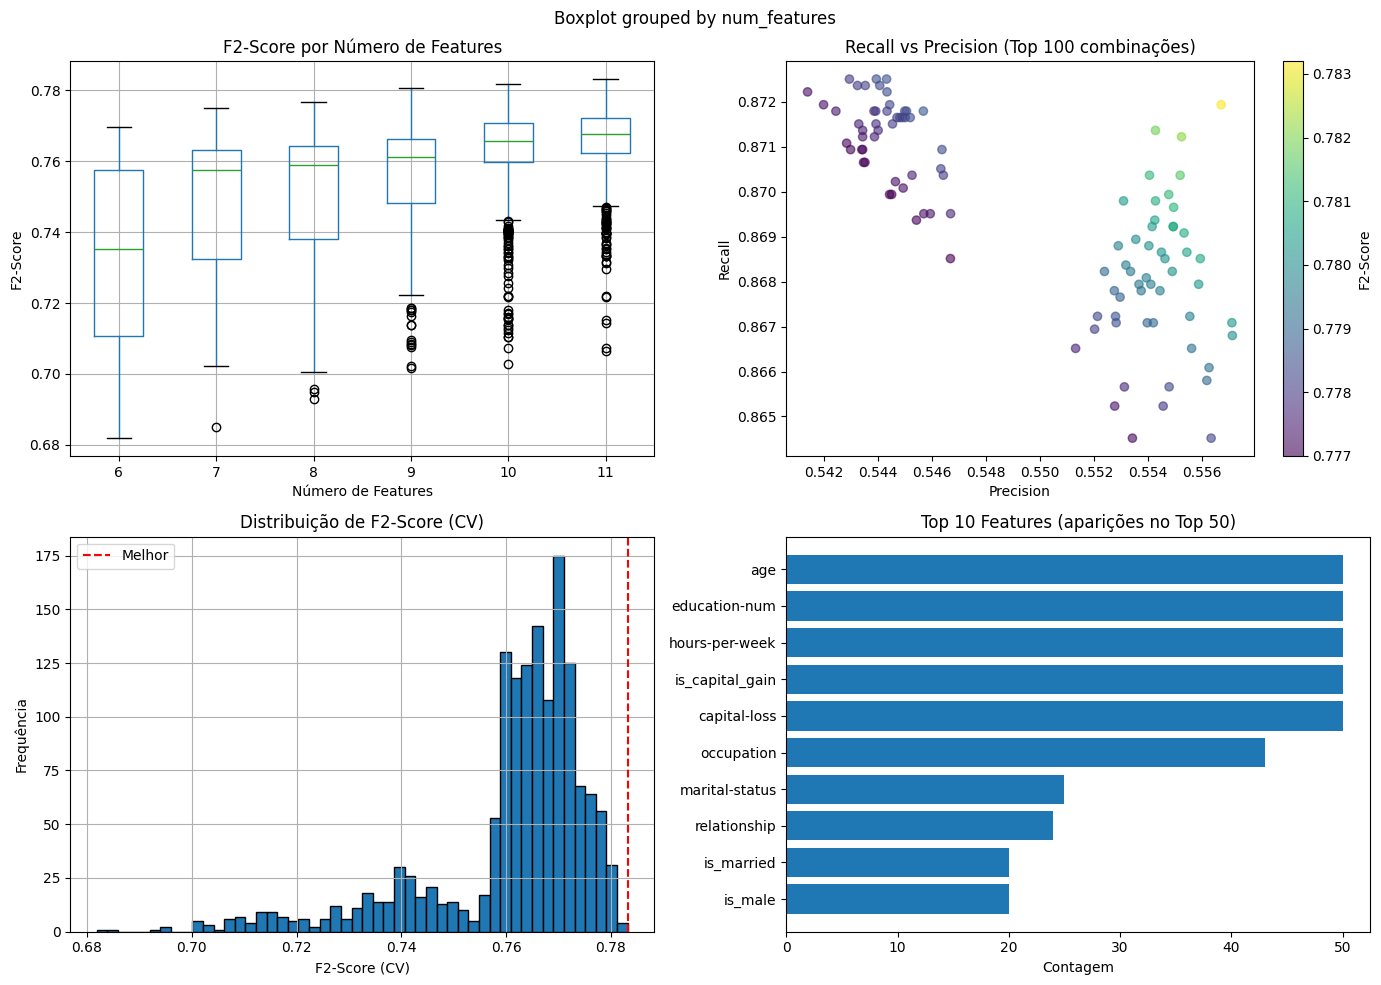


✅ Resultados salvos em: feature_combination_results.csv


In [0]:
import pandas as pd
import mlflow

# 5. Análise dos resultados

# Verificar se 'results' foi populado corretamente
if not isinstance(results, list) or len(results) == 0 or results == [...]:
    print("⚠️ A variável 'results' não está disponível na sessão.")
    print("📥 Carregando resultados dos logs do MLflow...\n")

    # Carregar resultados do MLflow
    mlflow.set_experiment("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")
    experiment = mlflow.get_experiment_by_name("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")

    if experiment is None:
        print("❌ ERRO: Experimento MLflow não encontrado.")
        print("\n📋 SOLUÇÃO:")
        print("   Execute Cell Run All Experiment primeiro para gerar os experimentos.")
        print("\n⚠️ NOTA: Cell pode levar várias horas dependendo do número de experimentos.")
        raise ValueError("Experimento MLflow não encontrado")

    # Buscar todas as runs do experimento
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

    if len(runs) == 0:
        print("❌ ERRO: Nenhuma run encontrada no experimento MLflow.")
        print("\n📋 SOLUÇÃO:")
        print("   Execute Cell Run All Experiments primeiro para gerar os experimentos.")
        raise ValueError("Nenhuma run encontrada no MLflow")

    # Reconstruir o DataFrame de resultados a partir das runs do MLflow
    results_data = []
    for idx, run in runs.iterrows():
        try:
            results_data.append({
                'experiment_id': int(run['tags.mlflow.runName'].split('_')[1]) if 'tags.mlflow.runName' in run and run['tags.mlflow.runName'] else idx + 1,
                'num_features': int(run['params.num_features']) if 'params.num_features' in run and pd.notna(run['params.num_features']) else None,
                'features': run['params.features'] if 'params.features' in run else '',
                'recall_cv_mean': run['metrics.recall_cv_mean'] if 'metrics.recall_cv_mean' in run else None,
                'precision_cv_mean': run['metrics.precision_cv_mean'] if 'metrics.precision_cv_mean' in run else None,
                'f2_cv_mean': run['metrics.f2_cv_mean'] if 'metrics.f2_cv_mean' in run else None,
                'f2_cv_std': run['metrics.f2_cv_std'] if 'metrics.f2_cv_std' in run else None,
                'status': 'success' if pd.notna(run.get('metrics.f2_cv_mean')) else 'failed'
            })
        except Exception as e:
            # Skip runs que não têm os dados esperados
            continue

    results_df = pd.DataFrame(results_data)
    print(f"✅ Carregados {len(results_df)} experimentos do MLflow.\n")
else:
    results_df = pd.DataFrame(results)

# Verificar se o DataFrame tem as colunas esperadas
if 'status' not in results_df.columns:
    print("❌ ERRO: DataFrame 'results_df' não contém a coluna 'status'.")
    print("\nColunas disponíveis:", results_df.columns.tolist())
    raise ValueError("Coluna 'status' não encontrada em results_df")

# Filtrar apenas experimentos bem-sucedidos
successful_results = results_df[results_df['status'] == 'success'].copy()

if len(successful_results) > 0:
    # Ordenar por F2-Score (métrica que favorece recall)
    successful_results = successful_results.sort_values('f2_cv_mean', ascending=False)

    print("="*80)
    print("TOP 20 COMBINAÇÕES DE FEATURES (ordenado por F2-Score)")
    print("="*80)
    display(successful_results[['experiment_id', 'num_features', 'features', 'recall_cv_mean', 'precision_cv_mean', 'f2_cv_mean', 'f2_cv_std']].head(20))

    print("\n" + "="*80)
    print("ESTATÍSTICAS GERAIS")
    print("="*80)
    print(f"\nMétricas médias por número de features:")
    stats_by_size = successful_results.groupby('num_features')[['recall_cv_mean', 'precision_cv_mean', 'f2_cv_mean', 'f2_cv_std']].agg(['mean', 'std', 'min', 'max'])
    display(stats_by_size)

    # Melhor combinação geral
    best_combo = successful_results.iloc[0]
    print("\n" + "="*80)
    print("⭐ MELHOR COMBINAÇÃO GERAL (F2-Score)")
    print("="*80)
    print(f"Experimento ID: {best_combo['experiment_id']}")
    print(f"Número de features: {best_combo['num_features']}")
    print(f"Features: {best_combo['features']}")
    print(f"\nMétricas:")
    print(f"  Recall (CV): {best_combo['recall_cv_mean']:.4f}")
    print(f"  Precision (CV): {best_combo['precision_cv_mean']:.4f}")
    print(f"  F2-Score (CV): {best_combo['f2_cv_mean']:.4f}")
    print(f"  F2-Score Std (CV): {best_combo['f2_cv_std']:.4f}")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Gráfico 1: F2-Score por número de features
    successful_results.boxplot(column='f2_cv_mean', by='num_features', ax=axes[0, 0])
    axes[0, 0].set_title('F2-Score por Número de Features')
    axes[0, 0].set_xlabel('Número de Features')
    axes[0, 0].set_ylabel('F2-Score')

    # Gráfico 2: Recall vs Precision (top 100)
    top_100 = successful_results.head(100)
    scatter = axes[0, 1].scatter(top_100['precision_cv_mean'], top_100['recall_cv_mean'],
                                  c=top_100['f2_cv_mean'], cmap='viridis', alpha=0.6)
    axes[0, 1].set_title('Recall vs Precision (Top 100 combinações)')
    axes[0, 1].set_xlabel('Precision')
    axes[0, 1].set_ylabel('Recall')
    plt.colorbar(scatter, ax=axes[0, 1], label='F2-Score')

    # Gráfico 3: Distribuição de F2-Score (CV)
    successful_results['f2_cv_mean'].hist(bins=50, ax=axes[1, 0], edgecolor='black')
    axes[1, 0].set_title('Distribuição de F2-Score (CV)')
    axes[1, 0].set_xlabel('F2-Score (CV)')
    axes[1, 0].set_ylabel('Frequência')
    axes[1, 0].axvline(best_combo['f2_cv_mean'], color='red', linestyle='--', label='Melhor')
    axes[1, 0].legend()

    # Gráfico 4: Top 10 features (contagem de aparições no top 50)
    top_50 = successful_results.head(50)
    all_top_features = []
    for features_str in top_50['features']:
        all_top_features.extend([f.strip() for f in features_str.split(',')])

    from collections import Counter
    feature_counts = Counter(all_top_features)
    top_features_df = pd.DataFrame(feature_counts.most_common(10), columns=['Feature', 'Count'])

    axes[1, 1].barh(top_features_df['Feature'], top_features_df['Count'])
    axes[1, 1].set_title('Top 10 Features (aparições no Top 50)')
    axes[1, 1].set_xlabel('Contagem')
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Salvar resultados em CSV
    results_csv_path = "feature_combination_results.csv"
    successful_results.to_csv(results_csv_path, index=False)
    print(f"\n✅ Resultados salvos em: {results_csv_path}")

else:
    print("⚠️ Nenhum experimento bem-sucedido encontrado.")

🔍 ANÁLISE: TREINO vs TESTE - Melhor Combinação

📋 Melhor combinação (Experimento 476):
   Features (11): ['age', 'education-num', 'hours-per-week', 'is_married', 'occupation', 'relationship', 'is_capital_gain', 'native-country', 'capital-loss', 'is_wife', 'sex_ord']
   F2-Score (CV): 0.7832


📊 COMPARAÇÃO: TREINO vs TESTE


,Métrica,Treino (60%),Teste (20%),GAP (Treino - Teste),GAP %
0,Recall,0.8856,0.8764,0.0092,1.04%
1,Precision,0.5654,0.5532,0.0122,2.15%
2,F1-Score,0.6902,0.6783,0.0119,1.72%
3,F2-Score,0.7955,0.7847,0.0108,1.36%
4,AUC,0.9167,0.9074,0.0093,1.01%



🔍 INTERPRETAÇÃO

📈 GAP Médio (todas métricas): 0.0107

✅ BOA GENERALIZAÇÃO (F2 Gap ≈ 0)
   O modelo não está sofrendo overfitting significativo.
   A performance no treino e teste é similar.


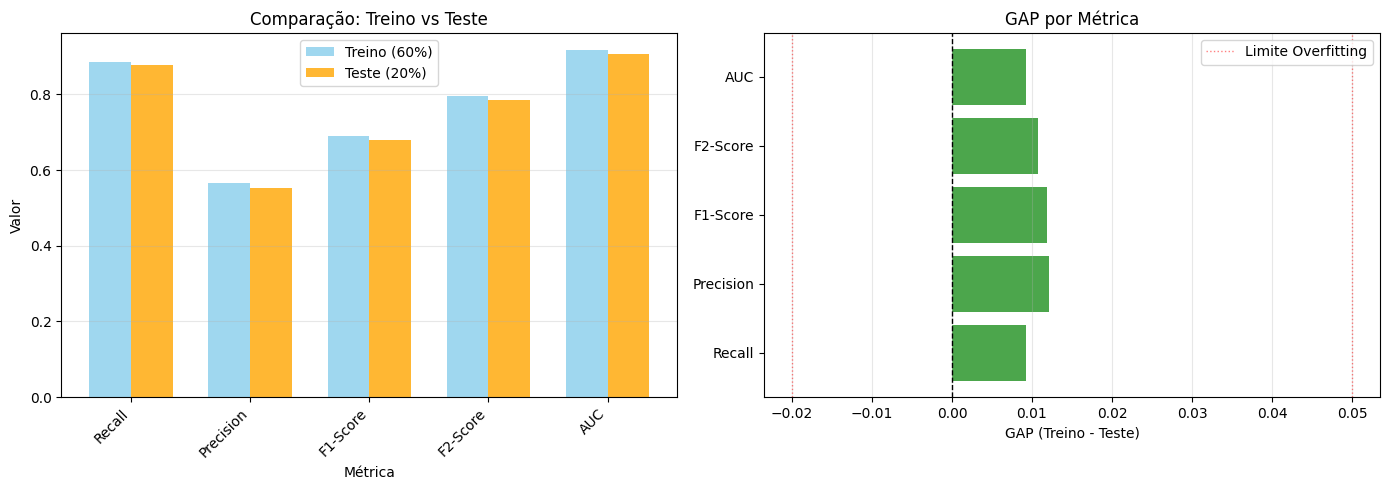


✅ ANÁLISE CONCLUÍDA


In [0]:
# Comparar performance Treino vs Teste APENAS da melhor combinação

if len(successful_results) > 0:
    print("="*100)
    print("🔍 ANÁLISE: TREINO vs TESTE - Melhor Combinação")
    print("="*100)

    # Pegar a melhor combinação (maior F2-Score no teste)
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}")
    print(f"   F2-Score (CV): {best_combo['f2_cv_mean']:.4f}\n")

    # Separar features numéricas, categóricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    categorical_in_combo = [f for f in best_features if f in all_categorical_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if categorical_in_combo:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # Criar pipeline
    pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    ('classifier',XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    # ====== TREINAR ======
    X_train_best = df_train[best_features]
    pipeline_best.fit(X_train_best, y_train)

    # ====== AVALIAR NO TREINO ======
    y_train_pred = pipeline_best.predict(X_train_best)
    y_train_pred_proba = pipeline_best.predict_proba(X_train_best)[:, 1]

    recall_train = recall_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f2_train = fbeta_score(y_train, y_train_pred, beta=2)
    auc_train = roc_auc_score(y_train, y_train_pred_proba)

    # ====== AVALIAR NO TESTE ======
    X_test_best = df_test[best_features]
    y_test_pred = pipeline_best.predict(X_test_best)
    y_test_pred_proba = pipeline_best.predict_proba(X_test_best)[:, 1]

    recall_test = recall_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    f2_test = fbeta_score(y_test, y_test_pred, beta=2)
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    # ====== CALCULAR GAP ======
    recall_gap = recall_train - recall_test
    precision_gap = precision_train - precision_test
    f1_gap = f1_train - f1_test
    f2_gap = f2_train - f2_test
    auc_gap = auc_train - auc_test

    # Criar DataFrame de comparação
    comparison_data = {
        'Métrica': ['Recall', 'Precision', 'F1-Score', 'F2-Score', 'AUC'],
        'Treino (60%)': [recall_train, precision_train, f1_train, f2_train, auc_train],
        'Teste (20%)': [recall_test, precision_test, f1_test, f2_test, auc_test],
        'GAP (Treino - Teste)': [recall_gap, precision_gap, f1_gap, f2_gap, auc_gap],
        'GAP %': [
            (recall_gap/recall_train*100) if recall_train > 0 else 0,
            (precision_gap/precision_train*100) if precision_train > 0 else 0,
            (f1_gap/f1_train*100) if f1_train > 0 else 0,
            (f2_gap/f2_train*100) if f2_train > 0 else 0,
            (auc_gap/auc_train*100) if auc_train > 0 else 0
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("\n" + "="*100)
    print("📊 COMPARAÇÃO: TREINO vs TESTE")
    print("="*100)
    display(comparison_df.style.format({
        'Treino (60%)': '{:.4f}',
        'Teste (20%)': '{:.4f}',
        'GAP (Treino - Teste)': '{:.4f}',
        'GAP %': '{:.2f}%'
    }))

    # Interpretação do GAP
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    avg_gap = comparison_df['GAP (Treino - Teste)'].mean()

    print(f"\n📈 GAP Médio (todas métricas): {avg_gap:.4f}\n")

    if f2_gap > 0.05:
        print("⚠️ OVERFITTING DETECTADO (F2 Gap > 0.05)")
        print("   O modelo performa significativamente melhor no treino que no teste.")
        print("   Sugestões:")
        print("   • Usar regularização mais forte (reduzir C na Logistic Regression)")
        print("   • Reduzir número de features")
        print("   • Usar cross-validation")
    elif f2_gap < -0.02:
        print("⚠️ INCONSISTÊNCIA (F2 Gap < -0.02)")
        print("   O modelo performa melhor no teste que no treino (raro).")
        print("   Verificar possíveis problemas nos dados.")
    else:
        print("✅ BOA GENERALIZAÇÃO (F2 Gap ≈ 0)")
        print("   O modelo não está sofrendo overfitting significativo.")
        print("   A performance no treino e teste é similar.")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Comparação Treino vs Teste
    metrics = comparison_df['Métrica']
    train_values = comparison_df['Treino (60%)']
    test_values = comparison_df['Teste (20%)']

    x = range(len(metrics))
    width = 0.35

    axes[0].bar([i - width/2 for i in x], train_values, width, label='Treino (60%)', alpha=0.8, color='skyblue')
    axes[0].bar([i + width/2 for i in x], test_values, width, label='Teste (20%)', alpha=0.8, color='orange')
    axes[0].set_xlabel('Métrica')
    axes[0].set_ylabel('Valor')
    axes[0].set_title('Comparação: Treino vs Teste')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Gráfico 2: GAP por Métrica
    gap_values = comparison_df['GAP (Treino - Teste)']
    colors = ['red' if gap > 0.05 else 'green' if abs(gap) < 0.02 else 'orange' for gap in gap_values]

    axes[1].barh(metrics, gap_values, color=colors, alpha=0.7)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].axvline(0.05, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Limite Overfitting')
    axes[1].axvline(-0.02, color='red', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].set_xlabel('GAP (Treino - Teste)')
    axes[1].set_title('GAP por Métrica')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE CONCLUÍDA")
    print("="*100)

else:
    print("⚠️ Execute primeiro a célula 21 (experimentos) para ter resultados disponíveis.")

## Train vs Test vs Validation Analysis

📊 ANÁLISE COMPLETA: TREINO (60%) vs VALIDAÇÃO (20%) vs TESTE (20%)

📋 Melhor combinação (Experimento 476):
   Features (11): ['age', 'education-num', 'hours-per-week', 'is_married', 'occupation', 'relationship', 'is_capital_gain', 'native-country', 'capital-loss', 'is_wife', 'sex_ord']


📊 COMPARAÇÃO: TREINO vs VALIDAÇÃO vs TESTE


,Métrica,Treino (60%),Validação (20%),Teste (20%),Desvio Padrão,Range
0,Recall,0.8856,0.8699,0.8764,0.0079,0.0157
1,Precision,0.5654,0.5540,0.5532,0.0068,0.0122
2,F1-Score,0.6902,0.6769,0.6783,0.0073,0.0133
3,F2-Score,0.7955,0.7808,0.7847,0.0076,0.0147
4,AUC,0.9167,0.9054,0.9074,0.0060,0.0113



🔍 INTERPRETAÇÃO

📈 Desvio Padrão Médio: 0.0071
📈 Range Médio: 0.0134

✅ EXCELENTE CONSISTÊNCIA
   O modelo performa de forma muito similar nos 3 conjuntos.
   Alta confiabilidade e boa generalização!

🎯 Análise Detalhada (F2-Score):
   • Melhor: Treino (0.7955)
   • Pior: Validação (0.7808)
   • Diferença: 0.0147

   ⚠️ Treino tem melhor performance → Possível leve overfitting


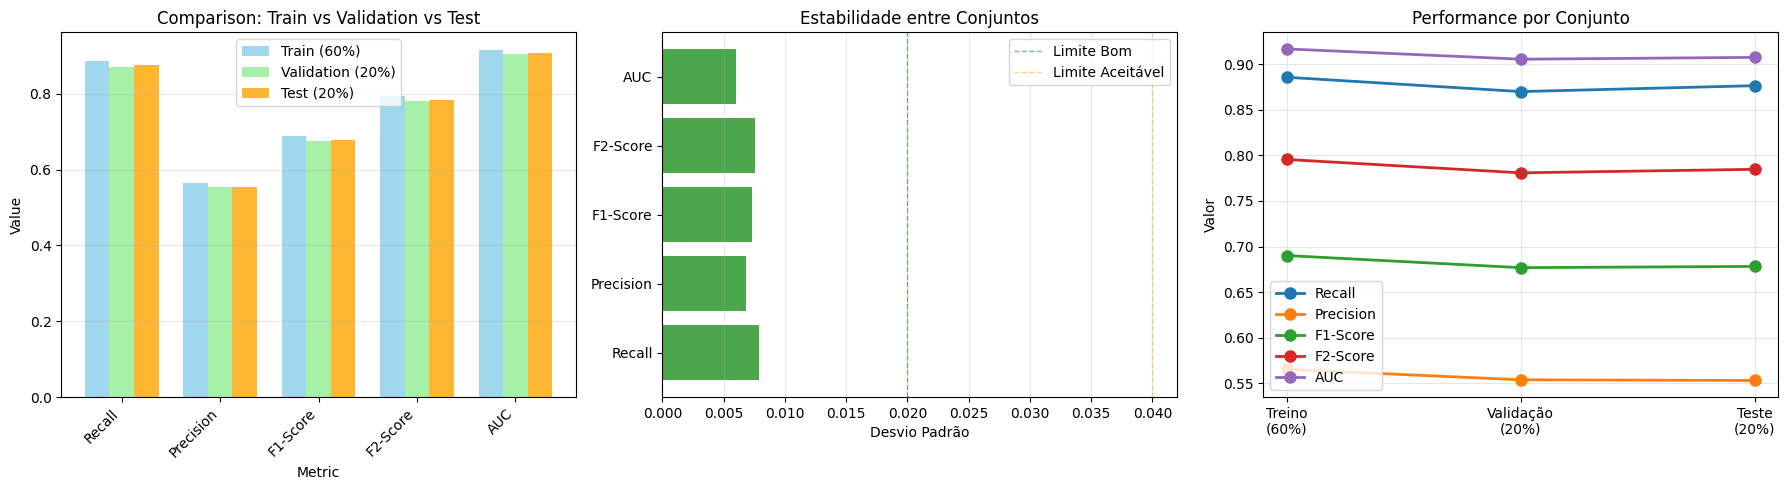


✅ ANÁLISE COMPLETA CONCLUÍDA

💡 Resumo:
   • Os 3 conjuntos têm 29,305, 9,768 e 9,769 registros
   • A melhor combinação usa 11 features
   • Desvio padrão médio entre conjuntos: 0.0071
   • F2-Score médio: 0.7870


In [0]:
# Comparar performance do melhor modelo em TODOS os 3 conjuntos

if len(successful_results) > 0:
    print("="*100)
    print("📊 ANÁLISE COMPLETA: TREINO (60%) vs VALIDAÇÃO (20%) vs TESTE (20%)")
    print("="*100)

    # Pegar a melhor combinação
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}\n")

    # Separar features numéricas, categóricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    categorical_in_combo = [f for f in best_features if f in all_categorical_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if categorical_in_combo:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)
    pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    # ====== TREINAR ======
    X_train_best = df_train[best_features]
    pipeline_best.fit(X_train_best, y_train)

    # ====== AVALIAR NO TREINO (60%) ======
    y_train_pred = pipeline_best.predict(X_train_best)
    y_train_pred_proba = pipeline_best.predict_proba(X_train_best)[:, 1]

    recall_train = recall_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f2_train = fbeta_score(y_train, y_train_pred, beta=2)
    auc_train = roc_auc_score(y_train, y_train_pred_proba)

    # ====== AVALIAR NA VALIDAÇÃO (20%) ======
    X_val_best = df_val[best_features]
    y_val_pred = pipeline_best.predict(X_val_best)
    y_val_pred_proba = pipeline_best.predict_proba(X_val_best)[:, 1]

    recall_val = recall_score(y_val, y_val_pred)
    precision_val = precision_score(y_val, y_val_pred)
    f1_val = f1_score(y_val, y_val_pred)
    f2_val = fbeta_score(y_val, y_val_pred, beta=2)
    auc_val = roc_auc_score(y_val, y_val_pred_proba)

    # ====== AVALIAR NO TESTE (20%) ======
    X_test_best = df_test[best_features]
    y_test_pred = pipeline_best.predict(X_test_best)
    y_test_pred_proba = pipeline_best.predict_proba(X_test_best)[:, 1]

    recall_test = recall_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    f2_test = fbeta_score(y_test, y_test_pred, beta=2)
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    # ====== CRIAR DATAFRAME DE COMPARAÇÃO ======
    comparison_3sets = pd.DataFrame({
        'Métrica': ['Recall', 'Precision', 'F1-Score', 'F2-Score', 'AUC'],
        'Treino (60%)': [recall_train, precision_train, f1_train, f2_train, auc_train],
        'Validação (20%)': [recall_val, precision_val, f1_val, f2_val, auc_val],
        'Teste (20%)': [recall_test, precision_test, f1_test, f2_test, auc_test]
    })

    # Calcular desvio padrão entre os 3 conjuntos (estabilidade)
    comparison_3sets['Desvio Padrão'] = comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].std(axis=1)
    comparison_3sets['Range'] = comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].max(axis=1) - \
                                comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].min(axis=1)

    print("\n" + "="*100)
    print("📊 COMPARAÇÃO: TREINO vs VALIDAÇÃO vs TESTE")
    print("="*100)
    display(comparison_3sets.style.format({
        'Treino (60%)': '{:.4f}',
        'Validação (20%)': '{:.4f}',
        'Teste (20%)': '{:.4f}',
        'Desvio Padrão': '{:.4f}',
        'Range': '{:.4f}'
    }).background_gradient(subset=['Desvio Padrão', 'Range'], cmap='RdYlGn_r'))

    # Interpretação
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    avg_std = comparison_3sets['Desvio Padrão'].mean()
    avg_range = comparison_3sets['Range'].mean()

    print(f"\n📈 Desvio Padrão Médio: {avg_std:.4f}")
    print(f"📈 Range Médio: {avg_range:.4f}\n")

    if avg_std < 0.02:
        print("✅ EXCELENTE CONSISTÊNCIA")
        print("   O modelo performa de forma muito similar nos 3 conjuntos.")
        print("   Alta confiabilidade e boa generalização!")
    elif avg_std < 0.04:
        print("✅ BOA CONSISTÊNCIA")
        print("   O modelo performa de forma consistente nos 3 conjuntos.")
        print("   Generalização adequada.")
    else:
        print("⚠️ VARIABILIDADE DETECTADA")
        print("   Há diferenças significativas entre os conjuntos.")
        print("   Revisar possível overfitting ou underfitting.")

    # Análise específica por conjunto
    print("\n🎯 Análise Detalhada (F2-Score):")
    f2_values = [f2_train, f2_val, f2_test]
    f2_labels = ['Treino', 'Validação', 'Teste']
    best_set_idx = f2_values.index(max(f2_values))
    worst_set_idx = f2_values.index(min(f2_values))

    print(f"   • Melhor: {f2_labels[best_set_idx]} ({f2_values[best_set_idx]:.4f})")
    print(f"   • Pior: {f2_labels[worst_set_idx]} ({f2_values[worst_set_idx]:.4f})")
    print(f"   • Diferença: {max(f2_values) - min(f2_values):.4f}")

    if best_set_idx == 0:
        print("\n   ⚠️ Treino tem melhor performance → Possível leve overfitting")
    elif f2_val > f2_train and f2_test > f2_train:
        print("\n   ⚠️ Validação e Teste superam Treino → Verificar dados ou randomização")
    else:
        print("\n   ✅ Performance equilibrada entre os conjuntos")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfico 1: Comparação por Métrica
    metrics = comparison_3sets['Métrica']
    x = range(len(metrics))
    width = 0.25

    axes[0].bar([i - width for i in x], comparison_3sets['Treino (60%)'], width,
                label='Train (60%)', alpha=0.8, color='skyblue')
    axes[0].bar([i for i in x], comparison_3sets['Validação (20%)'], width,
                label='Validation (20%)', alpha=0.8, color='lightgreen')
    axes[0].bar([i + width for i in x], comparison_3sets['Teste (20%)'], width,
                label='Test (20%)', alpha=0.8, color='orange')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Value')
    axes[0].set_title('Comparison: Train vs Validation vs Test')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Gráfico 2: Desvio Padrão (Estabilidade)
    colors_std = ['green' if std < 0.02 else 'orange' if std < 0.04 else 'red'
                  for std in comparison_3sets['Desvio Padrão']]
    axes[1].barh(metrics, comparison_3sets['Desvio Padrão'], color=colors_std, alpha=0.7)
    axes[1].axvline(0.02, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Limite Bom')
    axes[1].axvline(0.04, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Limite Aceitável')
    axes[1].set_xlabel('Desvio Padrão')
    axes[1].set_title('Estabilidade entre Conjuntos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

    # Gráfico 3: Linha - Evolução por Conjunto
    for i, metric in enumerate(metrics):
        values = [comparison_3sets.iloc[i]['Treino (60%)'],
                 comparison_3sets.iloc[i]['Validação (20%)'],
                 comparison_3sets.iloc[i]['Teste (20%)']]
        axes[2].plot(['Treino\n(60%)', 'Validação\n(20%)', 'Teste\n(20%)'], values,
                     marker='o', label=metric, linewidth=2, markersize=8)

    axes[2].set_ylabel('Valor')
    axes[2].set_title('Performance por Conjunto')
    axes[2].legend(loc='best')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE COMPLETA CONCLUÍDA")
    print("="*100)
    print("\n💡 Resumo:")
    print(f"   • Os 3 conjuntos têm {len(df_train):,}, {len(df_val):,} e {len(df_test):,} registros")
    print(f"   • A melhor combinação usa {len(best_features)} features")
    print(f"   • Desvio padrão médio entre conjuntos: {avg_std:.4f}")
    print(f"   • F2-Score médio: {(f2_train + f2_val + f2_test)/3:.4f}")

else:
    print("⚠️ Execute primeiro a célula 21 (experimentos) para ter resultados disponíveis.")

## Confusion Matrix & Precision-Recall Analysis

🏆 Melhor experimento: 476
   Features (11): ['age', 'education-num', 'hours-per-week', 'is_married', 'occupation', 'relationship', 'is_capital_gain', 'native-country', 'capital-loss', 'is_wife', 'sex_ord']
   F2-Score: 0.7832
   Precision: 0.5567
   Recall: 0.8719



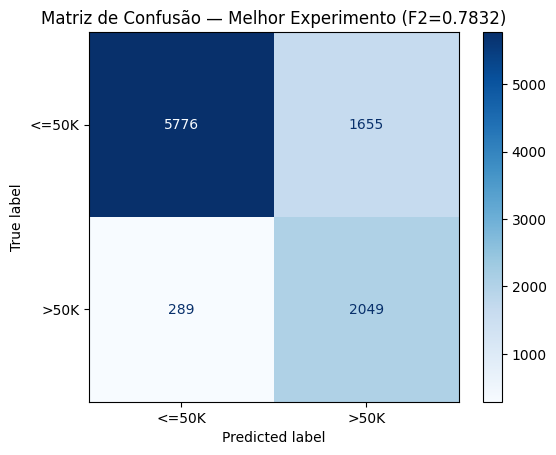

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Garantir que estamos pegando o MELHOR de TODOS os experimentos
successful_results = results_df[results_df['status'] == 'success'].sort_values('f2_cv_mean', ascending=False)

# Check if there are any successful experiments
if len(successful_results) == 0:
    print("❌ ERRO: Nenhum experimento foi executado com sucesso.")
    print(f"\nTotal de experimentos: {len(results_df)}")
    print(f"Experimentos bem-sucedidos: 0")
    print("\n📋 SOLUÇÃO:")
    print("   1. Verifique Cell 11 (Run All Experiments) para ver os erros dos experimentos")
    print("   2. Corrija os erros e execute Cell 11 novamente")
    print("   3. Depois execute esta célula novamente")
    raise ValueError("Nenhum experimento bem-sucedido encontrado")

best_combo = successful_results.iloc[0]
best_features = [f.strip() for f in best_combo['features'].split(',')]

print(f"🏆 Melhor experimento: {best_combo['experiment_id']}")
print(f"   Features ({len(best_features)}): {best_features}")
print(f"   F2-Score: {best_combo['f2_cv_mean']:.4f}")
print(f"   Precision: {best_combo['precision_cv_mean']:.4f}")
print(f"   Recall: {best_combo['recall_cv_mean']:.4f}\n")

# 2. Recriar o preprocessor para essa combinação
numeric_in_combo = [f for f in best_features if f in all_numeric_features]
categorical_in_combo = [f for f in best_features if f in all_categorical_features]
binary_in_combo = [f for f in best_features if f in all_binary_features]

transformers = []
if numeric_in_combo:
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    transformers.append(('num', numeric_transformer, numeric_in_combo))

if categorical_in_combo:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ])
    transformers.append(('cat', categorical_transformer, categorical_in_combo))

if binary_in_combo:
    binary_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])
    transformers.append(('bin', binary_transformer, binary_in_combo))

preprocessor_best = ColumnTransformer(transformers=transformers)
pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
])

# 3. Treinar e avaliar no teste
X_train_best = df_train[best_features]
X_test_best = df_test[best_features]

pipeline_best.fit(X_train_best, y_train)

y_test_pred = pipeline_best.predict(X_test_best)
y_test_pred_proba_best = pipeline_best.predict_proba(X_test_best)[:, 1]

# 4. Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title(f'Matriz de Confusão — Melhor Experimento (F2={best_combo["f2_cv_mean"]:.4f})')
plt.show()

🎯 THRESHOLD TUNING - Otimização de F2-Score

📊 Threshold default (0.50): F2 = 0.7808
📊 Threshold ótimo (0.35): F2 = 0.7910
📈 Ganho: +0.0101


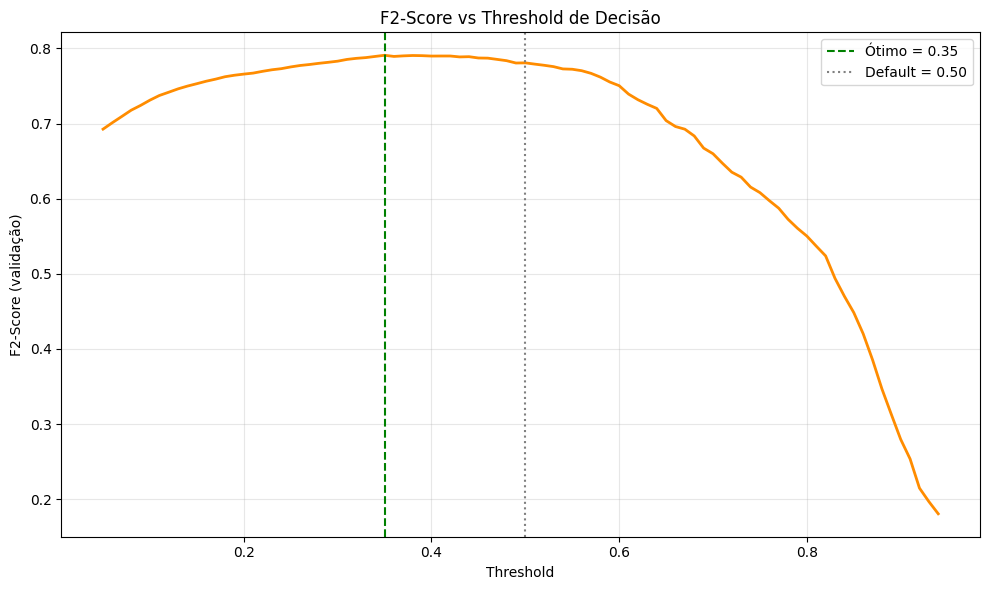


✅ RESULTADO NO CONJUNTO DE TESTE (avaliação final, imparcial)
F2 (threshold 0.50):        0.7847
F2 (threshold 0.35):        0.7863
Recall (threshold 0.35):     0.9350
Precision (threshold 0.35):  0.4807


In [0]:
# Threshold Tuning — otimizar decisão para F2-Score no conjunto de VALIDAÇÃO
import numpy as np
from sklearn.metrics import fbeta_score, precision_score, recall_score
import matplotlib.pyplot as plt

print("="*100)
print("🎯 THRESHOLD TUNING - Otimização de F2-Score")
print("="*100)

# 1. Preparar X_val com as mesmas features do melhor experimento
X_val_best = df_val[best_features]

# 2. Obter probabilidades no conjunto de VALIDAÇÃO (nunca visto pelo threshold search)
y_proba_val = pipeline_best.predict_proba(X_val_best)[:, 1]

# 3. Varrer thresholds e calcular F2 para cada um
thresholds = np.arange(0.05, 0.95, 0.01)
f2_scores = [fbeta_score(y_val, (y_proba_val >= t).astype(int), beta=2) for t in thresholds]

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2_val = f2_scores[best_idx]

print(f"\n📊 Threshold default (0.50): F2 = {fbeta_score(y_val, (y_proba_val >= 0.5).astype(int), beta=2):.4f}")
print(f"📊 Threshold ótimo ({best_threshold:.2f}): F2 = {best_f2_val:.4f}")
print(f"📈 Ganho: {best_f2_val - fbeta_score(y_val, (y_proba_val >= 0.5).astype(int), beta=2):+.4f}")

# 4. Visualização da curva F2 vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f2_scores, color='darkorange', lw=2)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Ótimo = {best_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default = 0.50')
plt.xlabel('Threshold')
plt.ylabel('F2-Score (validação)')
plt.title('F2-Score vs Threshold de Decisão')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. VALIDAÇÃO FINAL — aplicar o threshold escolhido no conjunto de TESTE (só agora)
X_test_best = df_test[best_features]  # já deve existir, recriado por segurança
y_proba_test = pipeline_best.predict_proba(X_test_best)[:, 1]
y_pred_test_tuned = (y_proba_test >= best_threshold).astype(int)

f2_test_tuned = fbeta_score(y_test, y_pred_test_tuned, beta=2)
f2_test_default = fbeta_score(y_test, (y_proba_test >= 0.5).astype(int), beta=2)

print(f"\n{'='*100}")
print("✅ RESULTADO NO CONJUNTO DE TESTE (avaliação final, imparcial)")
print(f"{'='*100}")
print(f"F2 (threshold 0.50):        {f2_test_default:.4f}")
print(f"F2 (threshold {best_threshold:.2f}):        {f2_test_tuned:.4f}")
print(f"Recall (threshold {best_threshold:.2f}):     {recall_score(y_test, y_pred_test_tuned):.4f}")
print(f"Precision (threshold {best_threshold:.2f}):  {precision_score(y_test, y_pred_test_tuned):.4f}")

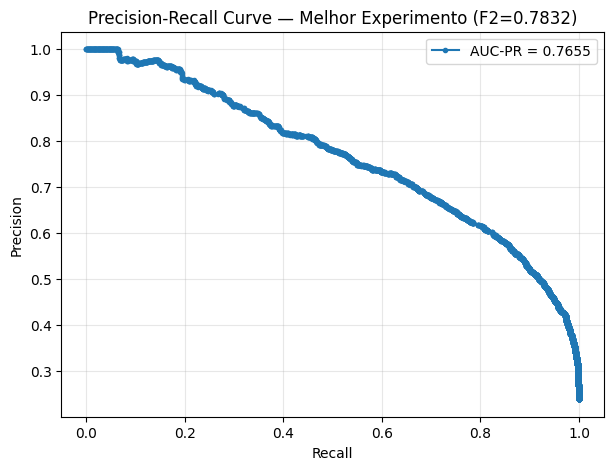

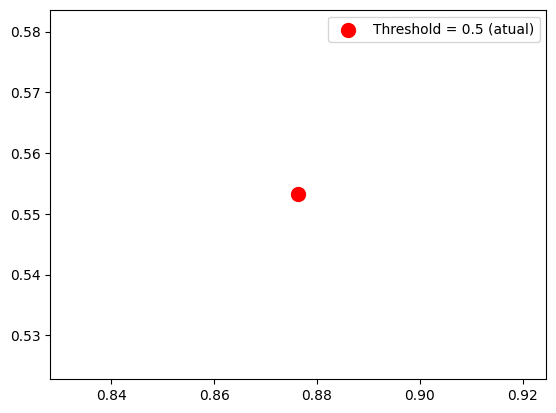

In [0]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba_best)
auc_pr = average_precision_score(y_test, y_test_pred_proba_best)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, marker='.', label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — Melhor Experimento (F2={best_combo["f2_cv_mean"]:.4f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Marcar o ponto do threshold atual (0.5) na curva
idx_threshold_05 = (thresholds >= 0.5).argmax()
plt.scatter(recall[idx_threshold_05], precision[idx_threshold_05],
            color='red', s=100, zorder=5, label='Threshold = 0.5 (atual)')
plt.legend()

In [0]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc_roc = roc_auc_score(y_test, y_test_pred_proba)
auc_pr = average_precision_score(y_test, y_test_pred_proba)

print("AUC-ROC:", auc_roc)
print("AUC-PR:", auc_pr)

AUC-ROC: 0.9074204091960263
AUC-PR: 0.765471661045578


F2-Score (Voting): 0.7807


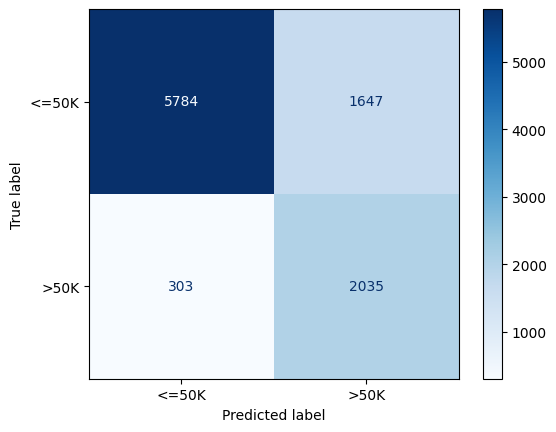

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import fbeta_score, confusion_matrix, ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=250, class_weight='balanced', random_state=42)
xgb_final = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')

voting_ensemble = VotingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb_final)],
    voting='soft',
    weights=[1, 2]
)

voting_clf = Pipeline([
    ('preprocessor', preprocessor_best),
    ('ensemble', voting_ensemble)
])
voting_clf.fit(X_train_best, y_train)

y_pred_voting = voting_clf.predict(X_test_best)
f2_voting = fbeta_score(y_test, y_pred_voting, beta=2)
print(f"F2-Score (Voting): {f2_voting:.4f}")

cm = confusion_matrix(y_test, y_pred_voting)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues')


📈 F2-Score XGBoost:  0.7847
📈 F2-Score Voting:   0.7807
📈 F2-Score Stacking: 0.7808

✅ MELHOR MODELO: XGBoost (F2=0.7847)


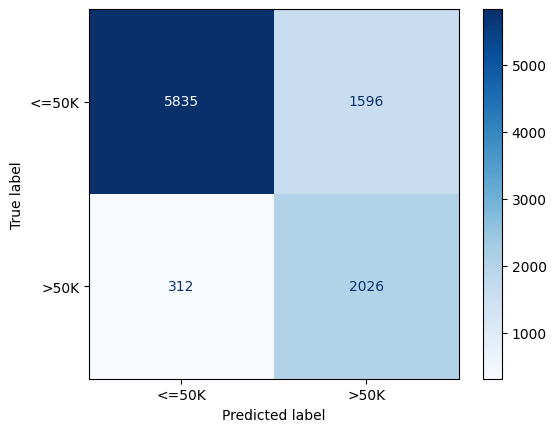

In [0]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, confusion_matrix, ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=250, class_weight='balanced', random_state=42)
xgb_final = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
meta_model = LogisticRegression(max_iter=250, class_weight='balanced', random_state=42)

stacking_ensemble = StackingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb_final)],
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf = Pipeline([
    ('preprocessor', preprocessor_best),
    ('ensemble', stacking_ensemble)
])
stacking_clf.fit(X_train_best, y_train)

# Previsões calculadas AQUI, sem depender da Cell 23
y_pred_xgb = pipeline_best.predict(X_test_best)       # da Cell 16
y_pred_voting = voting_clf.predict(X_test_best)         # da Cell 19
y_pred_stacking = stacking_clf.predict(X_test_best)

f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)
f2_voting = fbeta_score(y_test, y_pred_voting, beta=2)
f2_stacking = fbeta_score(y_test, y_pred_stacking, beta=2)

print(f"\n📈 F2-Score XGBoost:  {f2_xgb:.4f}")
print(f"📈 F2-Score Voting:   {f2_voting:.4f}")
print(f"📈 F2-Score Stacking: {f2_stacking:.4f}")

scores = {'XGBoost': f2_xgb, 'Voting': f2_voting, 'Stacking': f2_stacking}
best_model_name = max(scores, key=scores.get)
print(f"\n✅ MELHOR MODELO: {best_model_name} (F2={scores[best_model_name]:.4f})")
if best_model_name != 'XGBoost' and scores[best_model_name] - f2_xgb <= 0.005:
    print("   Ganho marginal — considerar manter XGBoost por simplicidade.")

cm = confusion_matrix(y_test, y_pred_stacking)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues')

## Feature Importance Analysis

🎯 FEATURE IMPORTANCE - Melhor Modelo (XGBoost)

📋 Melhor combinação (Experimento 476):
   Features (11): ['age', 'education-num', 'hours-per-week', 'is_married', 'occupation', 'relationship', 'is_capital_gain', 'native-country', 'capital-loss', 'is_wife', 'sex_ord']
   F2-Score (CV): 0.7832

🚀 XGBOOST - Feature Importance

✅ Feature Importance (ordenadas por importância, dummies OHE agregadas por coluna original):


,Feature,Importance,Importance_Pct
5,is_married,0.4747,47.47%
8,occupation,0.1803,18.03%
9,relationship,0.1408,14.08%
2,education-num,0.0697,6.97%
4,is_capital_gain,0.0364,3.64%
7,native-country,0.0262,2.62%
0,age,0.0213,2.13%
1,capital-loss,0.0187,1.87%
3,hours-per-week,0.0142,1.42%
6,is_wife,0.0093,0.93%


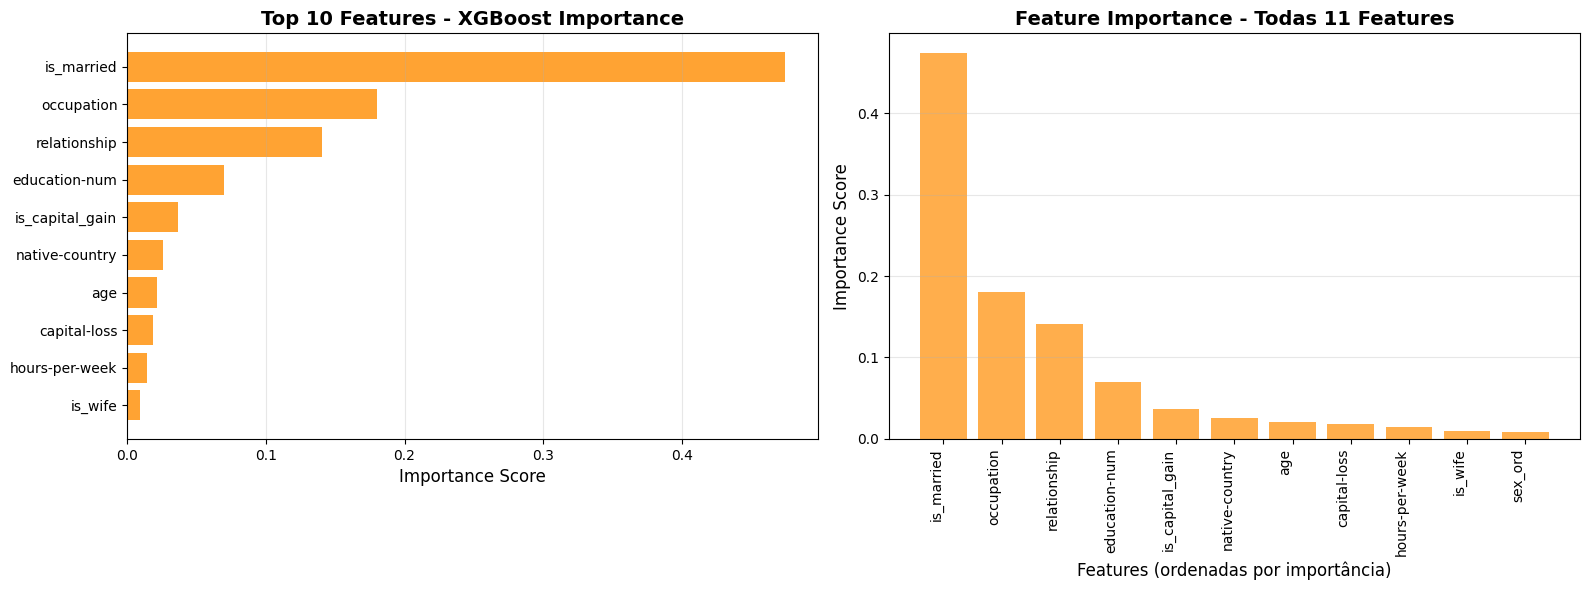


✅ ANÁLISE CONCLUÍDA

💡 Resumo:
   • Feature mais importante: is_married (0.4747 - 47.47%)
   • Top 3 features representam 79.58% da importância total
   • Top 5 features representam 90.19% da importância total


In [0]:
# Feature Importance for Best Model (XGBoost)
import numpy as np
import matplotlib.pyplot as plt

if len(successful_results) > 0:
    print("="*100)
    print("🎯 FEATURE IMPORTANCE - Melhor Modelo (XGBoost)")
    print("="*100)

    # Pegar a melhor combinação
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}")
    print(f"   F2-Score (CV): {best_combo['f2_cv_mean']:.4f}\n")

    # Separar features numéricas, categóricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    categorical_in_combo = [f for f in best_features if f in all_categorical_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if categorical_in_combo:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # ====== XGBOOST ======
    print("="*100)
    print("🚀 XGBOOST - Feature Importance")
    print("="*100)

    pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_best),
        ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    X_train_best = df_train[best_features]
    pipeline_xgb.fit(X_train_best, y_train)

    # Obter importâncias do XGBoost (nomes vêm do ColumnTransformer, já com OHE expandido)
    xgb_importances = pipeline_xgb.named_steps['classifier'].feature_importances_
    feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

    xgb_importance_df_raw = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_importances
    })

    # Agregar dummies do OHE de volta à coluna categórica original,
    # para que "occupation" apareça como 1 barra em vez de N barras por categoria
    def original_feature_name(transformed_name):
        name = transformed_name.split('__', 1)[-1]
        for col in categorical_in_combo:
            if name.startswith(col + '_'):
                return col
        return name

    xgb_importance_df_raw['Feature'] = xgb_importance_df_raw['Feature'].apply(original_feature_name)
    xgb_importance_df = xgb_importance_df_raw.groupby('Feature', as_index=False)['Importance'].sum()
    xgb_importance_df['Importance_Pct'] = (xgb_importance_df['Importance'] / xgb_importance_df['Importance'].sum()) * 100
    xgb_importance_df = xgb_importance_df.sort_values('Importance', ascending=False)

    print("\n✅ Feature Importance (ordenadas por importância, dummies OHE agregadas por coluna original):")
    display(xgb_importance_df.style.format({
        'Importance': '{:.4f}',
        'Importance_Pct': '{:.2f}%'
    }).background_gradient(subset=['Importance'], cmap='YlOrRd'))

    # ====== VISUALIZAÇÃO ======
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Top 10 Features - Bar Chart Horizontal
    xgb_plot_data = xgb_importance_df.head(10).sort_values('Importance')
    axes[0].barh(xgb_plot_data['Feature'], xgb_plot_data['Importance'], color='darkorange', alpha=0.8)
    axes[0].set_xlabel('Importance Score', fontsize=12)
    axes[0].set_title('Top 10 Features - XGBoost Importance', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')

    # Gráfico 2: Todas Features - Bar Chart Vertical
    xgb_sorted = xgb_importance_df.sort_values('Importance', ascending=False)
    axes[1].bar(range(len(xgb_sorted)), xgb_sorted['Importance'], color='darkorange', alpha=0.7)
    axes[1].set_xlabel('Features (ordenadas por importância)', fontsize=12)
    axes[1].set_ylabel('Importance Score', fontsize=12)
    axes[1].set_title(f'Feature Importance - Todas {len(xgb_sorted)} Features', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(xgb_sorted)))
    axes[1].set_xticklabels(xgb_sorted['Feature'], rotation=90, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE CONCLUÍDA")
    print("="*100)
    print(f"\n💡 Resumo:")
    print(f"   • Feature mais importante: {xgb_importance_df.iloc[0]['Feature']} ({xgb_importance_df.iloc[0]['Importance']:.4f} - {xgb_importance_df.iloc[0]['Importance_Pct']:.2f}%)")
    print(f"   • Top 3 features representam {xgb_importance_df.head(3)['Importance_Pct'].sum():.2f}% da importância total")
    print(f"   • Top 5 features representam {xgb_importance_df.head(5)['Importance_Pct'].sum():.2f}% da importância total")

else:
    print("⚠️ Execute primeiro a célula 11 (experimentos) para ter resultados disponíveis.")

## ROC CURVE

📊 ROC CURVE - XGBoost vs Stacking

📋 Melhor combinação (Experimento 476):
   Features (11): ['age', 'education-num', 'hours-per-week', 'is_married', 'occupation', 'relationship', 'is_capital_gain', 'native-country', 'capital-loss', 'is_wife', 'sex_ord']

Treinando XGBoost...

📈 ROC CURVE - XGBoost vs Stacking


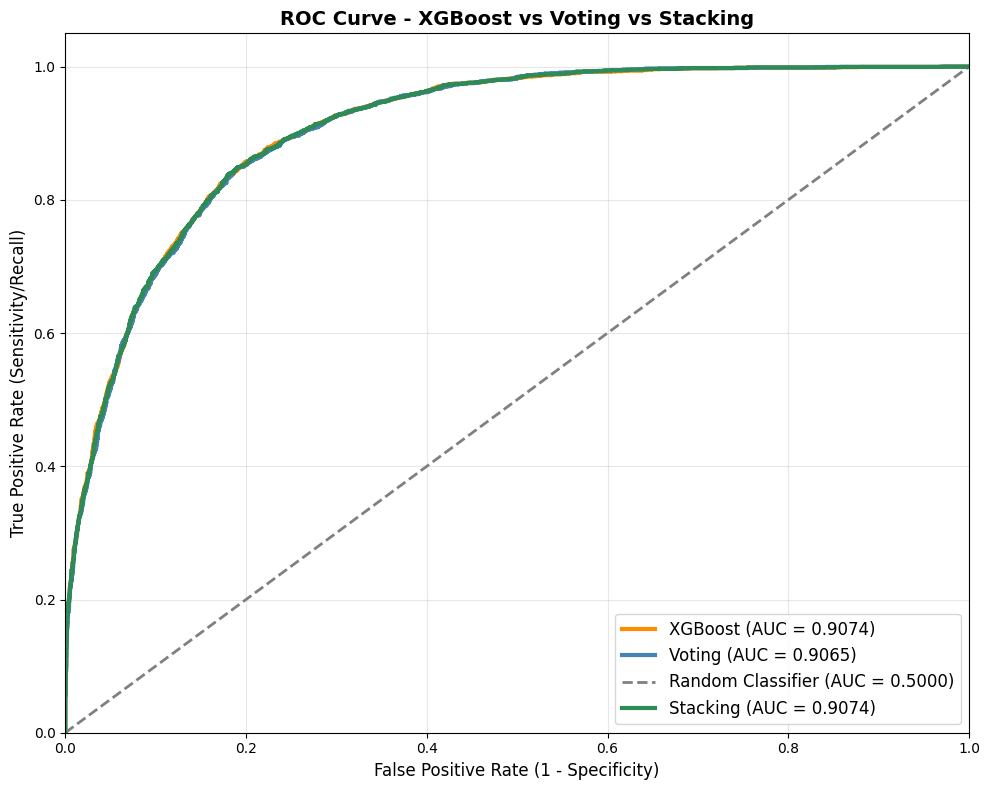


📊 MÉTRICAS: XGBOOST vs VOTING vs STACKING


,Métrica,XGBoost,Voting,Stacking
0,AUC,0.9074,0.9065,0.9074
1,Recall,0.8764,0.8704,0.8666
2,Precision,0.5532,0.5527,0.5594
3,F1-Score,0.6783,0.6761,0.6799
4,F2-Score,0.7847,0.7807,0.7808



🔍 INTERPRETAÇÃO

📈 F2-Score XGBoost: 0.7847
📈 F2-Score Voting:  0.7807
📈 F2-Score Stacking: 0.7808

✅ MELHOR MODELO: XGBoost (F2=0.7847)

➖ SEM DIFERENÇA RELEVANTE (Δ=-0.0040)
   Manter XGBoost isolado por simplicidade (menos custo computacional).

✅ ANÁLISE ROC CONCLUÍDA


In [0]:
# ROC Curve: XGBoost vs Stacking
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

if len(successful_results) > 0:
    print("="*100)
    print("📊 ROC CURVE - XGBoost vs Stacking")
    print("="*100)

    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}\n")

    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    categorical_in_combo = [f for f in best_features if f in all_categorical_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if categorical_in_combo:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # ====== XGBOOST ======
    print("Treinando XGBoost...")
    pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_best),
        ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    X_train_best = df_train[best_features]
    X_test_best = df_test[best_features]

    pipeline_xgb.fit(X_train_best, y_train)
    y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test_best)[:, 1]

    fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
    auc_xgb = auc(fpr_xgb, tpr_xgb)

    # Calcular ROC para Voting (sem plotar ainda)
    y_pred_proba_voting = voting_clf.predict_proba(X_test_best)[:, 1]
    fpr_vot, tpr_vot, _ = roc_curve(y_test, y_pred_proba_voting)
    auc_vot = auc(fpr_vot, tpr_vot)

        # Calcular ROC para Stacking
    y_pred_proba_stacking = stacking_clf.predict_proba(X_test_best)[:, 1]
    fpr_stk, tpr_stk, _ = roc_curve(y_test, y_pred_proba_stacking)
    auc_stk = auc(fpr_stk, tpr_stk)

    # ====== VISUALIZAÇÃO ======
    print("\n" + "="*100)
    print("📈 ROC CURVE - XGBoost vs Stacking")
    print("="*100)

    plt.figure(figsize=(10, 8))

    plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=3,
             label=f'XGBoost (AUC = {auc_xgb:.4f})')
    plt.plot(fpr_vot, tpr_vot, color='steelblue', lw=3,
             label=f'Voting (AUC = {auc_vot:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
             label='Random Classifier (AUC = 0.5000)')
    plt.plot(fpr_stk, tpr_stk, color='seagreen', lw=3,
         label=f'Stacking (AUC = {auc_stk:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
    plt.title('ROC Curve - XGBoost vs Voting vs Stacking', fontsize=14, fontweight='bold')    
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ====== MÉTRICAS DETALHADAS ======
    print("\n" + "="*100)
    print("📊 MÉTRICAS: XGBOOST vs VOTING vs STACKING")
    print("="*100)

    from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score

    y_pred_xgb = pipeline_xgb.predict(X_test_best)
    y_pred_voting = voting_clf.predict(X_test_best)
    y_pred_stacking = stacking_clf.predict(X_test_best)

    metrics_data = {
        'Métrica': ['AUC', 'Recall', 'Precision', 'F1-Score', 'F2-Score'],
        'XGBoost': [auc_xgb, recall_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb),
                    f1_score(y_test, y_pred_xgb), fbeta_score(y_test, y_pred_xgb, beta=2)],
        'Voting': [auc_vot, recall_score(y_test, y_pred_voting), precision_score(y_test, y_pred_voting),
                   f1_score(y_test, y_pred_voting), fbeta_score(y_test, y_pred_voting, beta=2)],
        'Stacking': [auc_stk, recall_score(y_test, y_pred_stacking), precision_score(y_test, y_pred_stacking),
             f1_score(y_test, y_pred_stacking), fbeta_score(y_test, y_pred_stacking, beta=2)]
    }

    metrics_df = pd.DataFrame(metrics_data)
    display(metrics_df.style.format({'XGBoost': '{:.4f}', 'Voting': '{:.4f}', 'Stacking': '{:.4f}'})
            .background_gradient(subset=['XGBoost', 'Voting','Stacking'], cmap='YlOrRd'))

    # ====== INTERPRETAÇÃO ======
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)
    f2_voting = fbeta_score(y_test, y_pred_voting, beta=2)
    f2_stacking = fbeta_score(y_test, y_pred_stacking, beta=2)
    diff = f2_voting - f2_xgb

    print(f"\n📈 F2-Score XGBoost: {f2_xgb:.4f}")
    print(f"📈 F2-Score Voting:  {f2_voting:.4f}")
    print(f"📈 F2-Score Stacking: {f2_stacking:.4f}")

    scores = {'XGBoost': f2_xgb, 'Voting': f2_voting, 'Stacking': f2_stacking}
    best_model_name = max(scores, key=scores.get)
    print(f"\n✅ MELHOR MODELO: {best_model_name} (F2={scores[best_model_name]:.4f})")
    if best_model_name != 'XGBoost' and diff <= 0.005:
        print("   Ganho marginal — considerar manter XGBoost por simplicidade.")
    elif diff > 0.005:
        print(f"\n✅ VOTING SUPERIOR (+{diff:.4f} em F2)")
        print("   Recomenda-se seguir com o modelo combinado.")
    elif diff < -0.005:
        print(f"\n✅ XGBOOST SUPERIOR ({diff:.4f} em F2)")
        print("   Ensemble não trouxe ganho — manter XGBoost isolado.")
    else:
        print(f"\n➖ SEM DIFERENÇA RELEVANTE (Δ={diff:.4f})")
        print("   Manter XGBoost isolado por simplicidade (menos custo computacional).")

    print("\n" + "="*100)
    print("✅ ANÁLISE ROC CONCLUÍDA")
    print("="*100)

else:
    print("⚠️ Execute primeiro a célula 11 (experimentos) para ter resultados disponíveis.")